In [1]:
import pickle
import json
import math

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [18]:
def plot_counts_scatter(
    y_test_counts,
    y_pred_counts,
    out_png="counts_pearsonr_like_attached.png",
    title="chrombpnet prediction",
    figsize=(8,8),
    point_size=50,
    label_fs=20,
    tick_fs=18,
    title_fs=18,
    text_fs=15,
    cbar_fs=15,
):
   
    x = np.asarray(y_test_counts).reshape(-1)
    y = np.asarray(y_pred_counts).reshape(-1)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # metrics
    pear = pearsonr(x, y)[0]
    spear = spearmanr(x, y)[0]

    # KDE density for point coloring
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # plot low-density points first, high-density last
    order = np.argsort(z)
    x, y, z = x[order], y[order], z[order]

    # axis limits
    xy_min = min(x.min(), y.min())
    xy_max = max(x.max(), y.max())
    pad = 0.03 * (xy_max - xy_min + 1e-8)
    lims = [xy_min - pad, xy_max + pad]

    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        x, y,
        c=z,
        s=point_size,
        cmap="viridis",
        edgecolors="none",
        rasterized=True
    )

    # diagonal y=x
    ax.plot(lims, lims, linestyle="--", linewidth=1)
    

    # ax.set_xlim(lims)
    # ax.set_ylim(lims)
    # ax.set_aspect("equal", adjustable="box")

    # labels
    ax.set_xlabel("y_test", fontsize=label_fs)
    ax.set_ylabel("y_pred", fontsize=label_fs)
    ax.set_title("Model Prediction", fontsize=title_fs)

    # ticks
    ax.tick_params(axis='both', labelsize=tick_fs)

    # stats box
    ax.text(
        0.05, 0.95,
        f"spearman R={spear:.2f}\nPearson R={pear:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=text_fs,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="black")
    )

    # colorbar
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Density", fontsize=label_fs)
    cbar.ax.tick_params(labelsize=cbar_fs)

    plt.grid()
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_png}")

In [19]:
df = pd.read_csv('./results/All_pred_test.csv')

In [20]:
y_test_counts = list(df['y_true'])
y_pred_counts = list(df['y_pred'])

y_595 = df['y_true'].iloc[-1]
y_pred_595 =  df['y_pred'].iloc[-1]

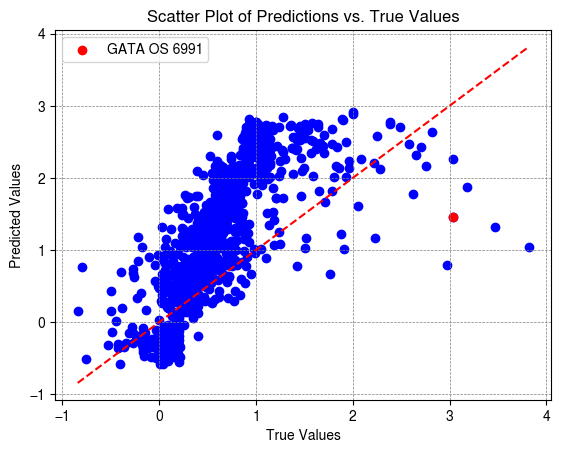

In [21]:
plt.scatter(y_test_counts, y_pred_counts, color='blue')
plt.scatter(y_595, y_pred_595, color='red', label='GATA OS 6991')
plt.plot([min(y_test_counts), max(y_test_counts)], [min(y_test_counts), max(y_test_counts)], color='red', linestyle='--')

plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of Predictions vs. True Values')
# plt.xlim([-0.25,4])
# plt.ylim([-0.25,4])
plt.legend()
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.5)

In [ ]:
#################

In [22]:
df = pd.read_csv('./results/Test_only_pred_test.csv')

y_test_counts = list(df['y_test'])
y_pred_counts = list(df['y_pred'])

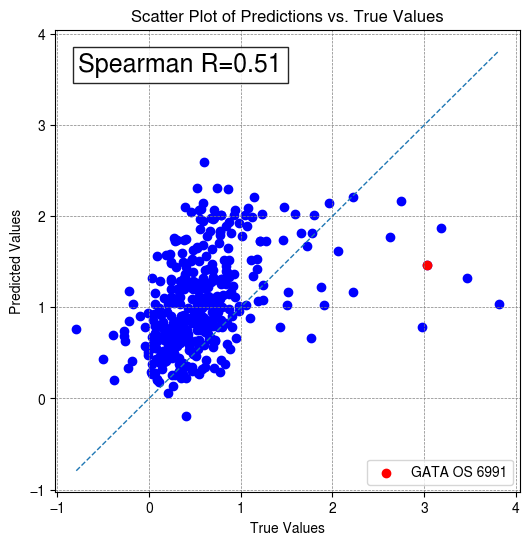

In [23]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_test_counts, y_pred_counts, color='blue')
pear = pearsonr(y_test_counts, y_pred_counts)[0]
spear = spearmanr(y_test_counts, y_pred_counts)[0]

ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title('Scatter Plot of Predictions vs. True Values')
plt.scatter(y_595, y_pred_595, color='red', label='GATA OS 6991')
ax.text(
    0.05, 0.95,
    f"Spearman R={spear:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=18,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="black")
)
ax.plot([min(y_test_counts), max(y_test_counts)], [min(y_test_counts), max(y_test_counts)], linestyle="--", linewidth=1)
plt.legend()
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.5)

In [136]:
##############

In [9]:
df = pd.read_csv('./results/gnn_rf_tad_hit_metrics_all.csv')

In [10]:
df = df[['pearson', 'spearman']]

/lsf_tmp/287119223.tmpdir/ipykernel_4076978/2026667249.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['pearson'], df['spearman']],


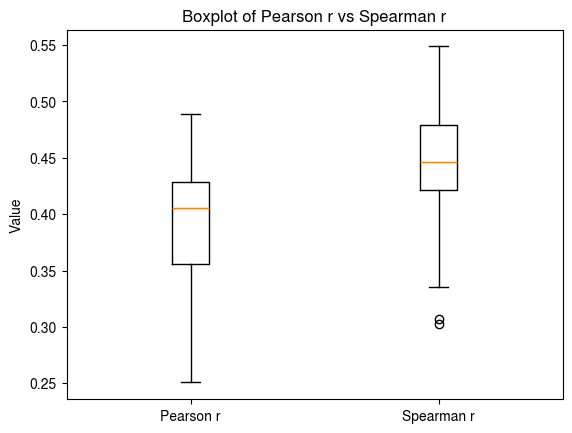

In [11]:
plt.boxplot([df['pearson'], df['spearman']],
            labels=['Pearson r', 'Spearman r'])
plt.ylabel("Value")
plt.title("Boxplot of Pearson r vs Spearman r")
plt.savefig('./results/correlation.pdf')

In [158]:
####################

In [159]:
DROP_COLUMNS = [
    "WGATAR_position",
    "WGATAR_chr",
    "WGATAR_start",
    "WGATAR_end",
]


In [ ]:
df_rd = pd.read_csv('./results/gnn_rf_tad_hit_records_all.pkl')

In [161]:
df_rd = df_rd[['train_tads', 'test_tads', 'gnn_embed_vectors_json']]

In [162]:
df = pd.read_pickle('./dataset/features_table.pkl')

tad = pd.read_csv('./dataset/TAD.csv', index_col=0)
tad = tad.drop_duplicates()

df = df.merge(tad, on='WGATAR_id', how='left')
df.drop(DROP_COLUMNS, axis=1, inplace=True)

In [163]:
##################

In [164]:
import shap

In [165]:
def ABS_SHAP(df_shap,df, max_display=10, figsize=(8,8), plot=True):
    #import matplotlib as plt
    # Make a copy of the input data
    shap_v = pd.DataFrame(df_shap)
    feature_list = df.columns
    shap_v.columns = feature_list
    df_v = df.copy().reset_index().drop('index',axis=1)
    
    # Determine the correlation in order to plot with different colors
    corr_list = list()
    for i in feature_list:
        b = np.corrcoef(shap_v[i],df_v[i])[1][0]
        corr_list.append(b)
    corr_df = pd.concat([pd.Series(feature_list),pd.Series(corr_list)],axis=1).fillna(0)
    # Make a data frame. Column 1 is the feature, and Column 2 is the correlation coefficient
    corr_df.columns  = ['Variable','Corr']
    corr_df['Sign'] = np.where(corr_df['Corr']>0,'mediumseagreen','silver')
    
    # Plot it
    
    shap_abs = np.abs(shap_v)
    k=pd.DataFrame(shap_abs.mean()).reset_index()
    k.columns = ['Variable','SHAP_abs']
    k1 = k.merge(corr_df,left_on = 'Variable',right_on='Variable',how='inner')
    k1 = k1.sort_values(by='SHAP_abs',ascending = True)
    k2 = k1.tail(max_display)
    colorlist = k2['Sign']
    if plot:
        plt.figure(figsize=(11,11))
        sns.set(font_scale=1, style='whitegrid')
        ax = k2.plot.barh(x='Variable',y='SHAP_abs',color = colorlist, figsize=figsize,legend=False)
        ax.set_xlabel("SHAP Value (GREEN = Positive Impact)")
        plt.tight_layout()
    return k1

In [166]:
import copy

embedding_rows = [f"gnn_emb_{i}" for i in range(8)]
shap_list = []
for i, r in df_rd.iterrows():
    print(i)    
    df_copy = copy.deepcopy(df)
    train = r['train_tads'].split(';')
    test = r['test_tads'].split(';')
    vec_str = r['gnn_embed_vectors_json']
    
    em = pd.DataFrame(json.loads(vec_str))
    df_copy = df_copy.merge(em, on='WGATAR_id', how = 'inner')
    
    df_train = df_copy[df_copy['Hudep2_TAD_position'].isin(train)]
    df_test = df_copy[df_copy['Hudep2_TAD_position'].isin(test)]

    y_train = df_train['effect_value']
    X_train = df_train.drop(['effect_value','Hudep2_TAD_position', 'WGATAR_id'], axis=1)
    X_train = X_train.fillna(0)
    
    y_test = df_test['effect_value']
    X_test = df_test.drop(['effect_value','Hudep2_TAD_position', 'WGATAR_id'], axis=1)
    X_test = X_test.fillna(0)
    
    label = X_test.columns

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    rf = RandomForestRegressor(
        n_estimators=1000,
        max_depth=None,
        min_samples_leaf=1,
        max_features=0.4,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)
    shap_values_df = pd.DataFrame(shap_values, columns = label)
    x_test_df = pd.DataFrame(X_test, columns = label)
    impact = ABS_SHAP(shap_values_df, x_test_df, plot=False)
    
    integer_rows = impact[impact['Variable'].isin(embedding_rows)]
    s = integer_rows.sum()        
    impact_filtered = impact[~impact['Variable'].isin(embedding_rows)]
    impact_filtered = impact_filtered.reset_index(drop=True)
    impact_filtered.loc[len(impact_filtered)] = ['network_embedding', s.SHAP_abs, s.Corr, 'mediumseagreen']
        
    shap_list.append(impact_filtered)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64


In [167]:
dfs = []
for f in shap_list:
    f = f.sort_values(by='Variable', ignore_index=True)
    dfs.append(copy.deepcopy(f))
for f in dfs:
    var = f['Variable']

In [168]:
cols = ['SHAP_abs', 'Corr']
stacked = np.stack([df[cols].values for df in dfs], axis=0)  # shape: (n_dfs, n_rows, n_cols)

# Compute statistics across the 0th axis (i.e., across DataFrames)
mean_df = pd.DataFrame(stacked.mean(axis=0), columns=[f"{c}_mean" for c in cols])
std_df = pd.DataFrame(stacked.std(axis=0, ddof=1), columns=[f"{c}_std" for c in cols])  # ddof=1 for sample std

# Optionally combine them
final_df = pd.concat([mean_df, std_df], axis=1)
final_df['Var'] = var

In [169]:
sign_color = np.where(final_df['Corr_mean'] > 0, 'mediumseagreen', 'silver')
final_df["sign"] = sign_color

In [170]:
final_df = final_df.sort_values(by='SHAP_abs_mean',ascending = True)
k2 = final_df.tail(15)

In [171]:
# k2.to_csv('top_15_shap.csv', index=None)
# final_df.to_csv('all_shap.csv', index=None)

<Figure size 1100x1100 with 0 Axes>

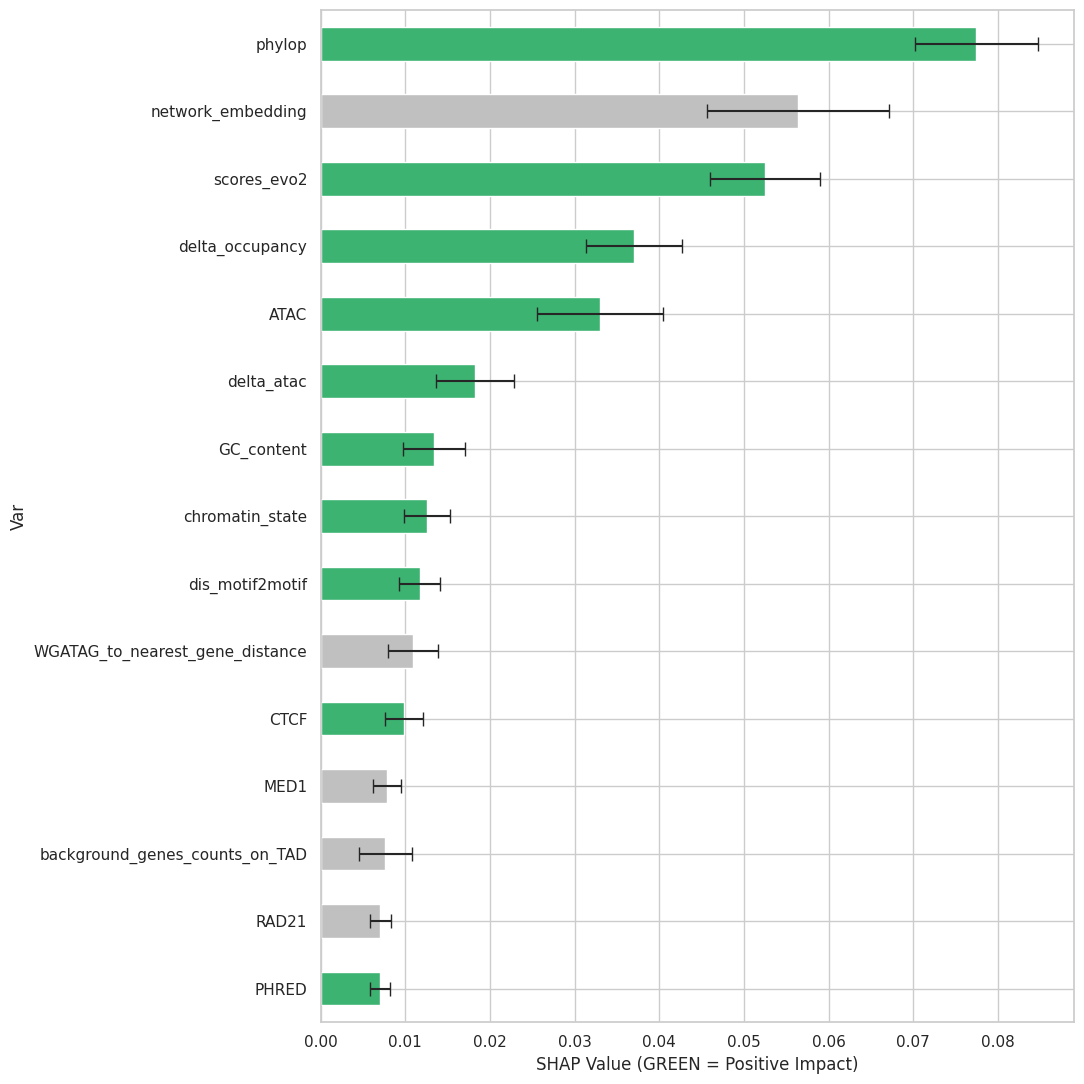

In [172]:
figsize=(11,11)
colorlist = k2['sign']
plt.figure(figsize=(11,11))
sns.set(font_scale=1, style='whitegrid')
ax = k2.plot.barh(x='Var',y='SHAP_abs_mean',xerr='SHAP_abs_std', color = colorlist, figsize=(11,11),legend=False, capsize=5)
ax.set_xlabel("SHAP Value (GREEN = Positive Impact)")
plt.tight_layout()
# plt.savefig('shap_features.pdf')